# Exploration du dataset Amazon Reviews

Dans cette partie, nous explorons le dataset Amazon Reviews afin de comprendre sa structure générale avant de passer au prétraitement et à la classification des avis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

## Chargement du dataset

Nous commençons par charger le fichier contenant les avis Amazon.

In [3]:
file_path = "../data/amazon_reviews.txt"
df = pd.read_csv(file_path, sep="\t")
df.head()

,DOC_ID,LABEL,RATING,VERIFIED_PURCHASE,PRODUCT_CATEGORY,PRODUCT_ID,PRODUCT_TITLE,REVIEW_TITLE,REVIEW_TEXT
0,1,__label1__,4,N,PC,B00008NG7N,"Targus PAUK10U Ultra Mini USB Keypad, Black",useful,"When least you think so, this product will save the day. Just keep it around just in case you need it for something."
1,2,__label1__,4,Y,Wireless,B00LH0Y3NM,Note 3 Battery : Stalion Strength Replacement 3200mAh Li-Ion Battery for Samsung Galaxy Note 3 [24-Month Warranty] with NFC Chip + Google Wallet Capable,New era for batteries,Lithium batteries are something new introduced in the market there average developing cost is relatively high but Stallion doesn't compromise on quality and provides us with the best at a low cost...
2,3,__label1__,3,N,Baby,B000I5UZ1Q,"Fisher-Price Papasan Cradle Swing, Starlight",doesn't swing very well.,I purchased this swing for my baby. She is 6 months now and has pretty much out grown it. It is very loud and doesn't swing very well. It is beautiful though. I love the colors and it has a lot of...
3,4,__label1__,4,N,Office Products,B003822IRA,Casio MS-80B Standard Function Desktop Calculator,Great computing!,I was looking for an inexpensive desk calcolatur and here it is. It works and does everything I need. Only issue is that it tilts slightly to one side so when I hit any keys it rocks a little bit....
4,5,__label1__,4,N,Beauty,B00PWSAXAM,Shine Whitening - Zero Peroxide Teeth Whitening System - No Sensitivity,Only use twice a week,"I only use it twice a week and the results are great. I have used other teeth whitening solutions and most of them, for the same results I would have to use it at least three times a week. Will ke..."


## Dimensions du dataset

Nous affichons le nombre de lignes et de colonnes afin d’avoir une première idée de la taille du dataset.

In [4]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 21000
Nombre de colonnes : 9


## Colonnes du dataset

Nous affichons les noms des colonnes afin d’identifier les variables disponibles dans le dataset.

In [5]:
df.columns

Index(['DOC_ID', 'LABEL', 'RATING', 'VERIFIED_PURCHASE', 'PRODUCT_CATEGORY',
       'PRODUCT_ID', 'PRODUCT_TITLE', 'REVIEW_TITLE', 'REVIEW_TEXT'],
      dtype='str')

Le dataset contient 9 colonnes :

- `DOC_ID` : identifiant de l’avis
- `LABEL` : classe associée à l’avis
- `RATING` : note donnée au produit
- `VERIFIED_PURCHASE` : indique si l’achat est vérifié ou non
- `PRODUCT_CATEGORY` : catégorie du produit
- `PRODUCT_ID` : identifiant du produit
- `PRODUCT_TITLE` : titre du produit
- `REVIEW_TITLE` : titre de l’avis
- `REVIEW_TEXT` : texte complet de l’avis

## Informations générales sur le dataset

Nous affichons les informations générales du dataset afin d’identifier le type des variables et de vérifier la présence éventuelle de valeurs manquantes.

In [6]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   DOC_ID             21000 non-null  int64
 1   LABEL              21000 non-null  str  
 2   RATING             21000 non-null  int64
 3   VERIFIED_PURCHASE  21000 non-null  str  
 4   PRODUCT_CATEGORY   21000 non-null  str  
 5   PRODUCT_ID         21000 non-null  str  
 6   PRODUCT_TITLE      21000 non-null  str  
 7   REVIEW_TITLE       21000 non-null  str  
 8   REVIEW_TEXT        21000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 1.4 MB


DOC_ID               0
LABEL                0
RATING               0
VERIFIED_PURCHASE    0
PRODUCT_CATEGORY     0
PRODUCT_ID           0
PRODUCT_TITLE        0
REVIEW_TITLE         0
REVIEW_TEXT          0
dtype: int64

L’analyse montre que le dataset contient 21 000 observations et 9 colonnes.

Toutes les colonnes possèdent 21 000 valeurs non nulles. La vérification avec `df.isnull().sum()` confirme également qu’il n’y a aucune valeur manquante dans le dataset.

Le dataset contient deux variables numériques (`DOC_ID` et `RATING`) et sept variables textuelles ou catégorielles.

## Analyse de la variable cible

Nous analysons la colonne `LABEL`, qui représente la classe associée à chaque avis.  
Cette étape permet de vérifier la répartition des classes dans le dataset.

La variable `LABEL` contient deux classes :

- `__label1__` : faux avis
- `__label2__` : avis authentique

In [7]:
df["LABEL"] = df["LABEL"].replace({
    "__label1__": "Faux avis",
    "__label2__": "Avis authentique"
})

In [8]:
label_distribution = pd.DataFrame({
    "Nombre": df["LABEL"].value_counts(),
    "Pourcentage": df["LABEL"].value_counts(normalize=True) * 100
})

label_distribution

,Nombre,Pourcentage
LABEL,,
Faux avis,10500,50.0
Avis authentique,10500,50.0


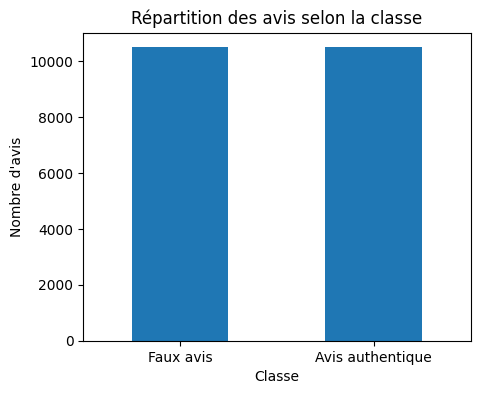

In [9]:
plt.figure(figsize=(5, 4))

label_distribution["Nombre"].plot(kind="bar")

plt.title("Répartition des avis selon la classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)

plt.show()

Le tableau et le graphique montrent que les deux classes sont parfaitement équilibrées, avec 10 500 avis pour chaque classe, soit 50 % du dataset pour chacune.

Cet équilibre est important pour la suite, car le modèle ne sera pas biaisé vers une classe majoritaire.

## Analyse des notes des avis

Nous analysons la colonne `RATING`, qui correspond à la note attribuée au produit dans chaque avis.  
Cette analyse permet de comprendre la répartition des notes dans le dataset.

In [10]:
rating_distribution = pd.DataFrame({
    "Nombre": df["RATING"].value_counts().sort_index(),
    "Pourcentage": df["RATING"].value_counts(normalize=True).sort_index() * 100
})

rating_distribution

,Nombre,Pourcentage
RATING,,
1,1757,8.366667
2,1192,5.676190
3,1868,8.895238
4,3973,18.919048
5,12210,58.142857


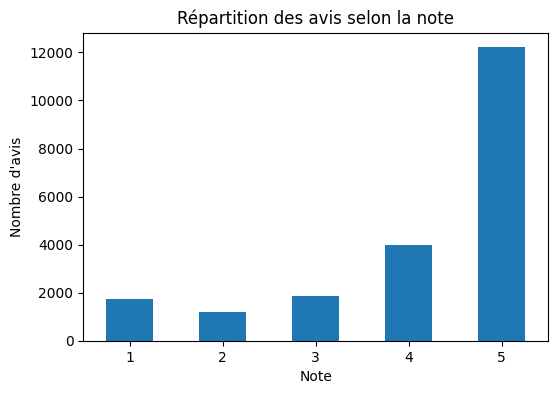

In [11]:
plt.figure(figsize=(6, 4))
rating_distribution["Nombre"].plot(kind="bar")

plt.title("Répartition des avis selon la note")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)

plt.show()

La distribution des notes montre que les avis sont majoritairement positifs.  
La note 5 est la plus fréquente avec 12 210 avis, soit environ 58 % du dataset.  
Les notes 4 et 5 représentent ensemble une grande partie des avis, ce qui indique que beaucoup de produits ont reçu des évaluations positives.

## Relation entre la note des avis et la classe

Nous croisons la colonne `RATING` avec la variable cible `LABEL` afin d’observer la répartition des faux avis et des avis authentiques selon la note attribuée.

In [12]:
rating_label_count = pd.crosstab(
    df["RATING"],
    df["LABEL"]
)

rating_label_percent = pd.crosstab(
    df["RATING"],
    df["LABEL"],
    normalize="index"
) * 100

rating_label_summary = (
    rating_label_count.astype(str)
    + " ("
    + rating_label_percent.round(2).astype(str)
    + "%)"
)

rating_label_summary.columns.name = None
rating_label_summary.index.name = "Note"

rating_label_summary

,Avis authentique,Faux avis
Note,,
1,868 (49.4%),889 (50.6%)
2,565 (47.4%),627 (52.6%)
3,942 (50.43%),926 (49.57%)
4,1974 (49.69%),1999 (50.31%)
5,6151 (50.38%),6059 (49.62%)


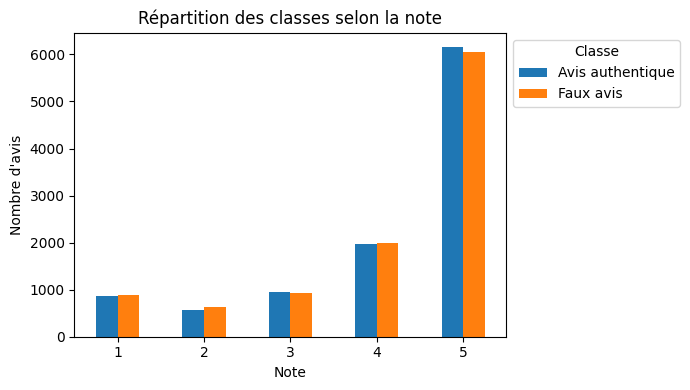

In [13]:
rating_label_plot = pd.crosstab(
    df["RATING"],
    df["LABEL"]
)

ax = rating_label_plot.plot(kind="bar", figsize=(7, 4))

plt.title("Répartition des classes selon la note")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)

plt.legend(title="Classe", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

Le croisement entre `RATING` et `LABEL` montre que, pour chaque note, les proportions de faux avis et d’avis authentiques sont proches de 50 %.

Cela signifie que la note attribuée au produit ne permet pas, à elle seule, de distinguer clairement les faux avis des avis authentiques.

## Analyse des achats vérifiés

Nous analysons la colonne `VERIFIED_PURCHASE`, qui indique si l’avis provient d’un achat vérifié ou non.  
Cette information peut être intéressante pour comprendre la relation entre les avis authentiques, les faux avis et le statut d’achat vérifié.

In [14]:
df["VERIFIED_PURCHASE"] = df["VERIFIED_PURCHASE"].replace({
    "Y": "Achat vérifié",
    "N": "Achat non vérifié"
})

In [15]:
verified_distribution = pd.DataFrame({
    "Nombre": df["VERIFIED_PURCHASE"].value_counts(),
    "Pourcentage": df["VERIFIED_PURCHASE"].value_counts(normalize=True) * 100
})

verified_distribution

,Nombre,Pourcentage
VERIFIED_PURCHASE,,
Achat vérifié,11698,55.704762
Achat non vérifié,9302,44.295238


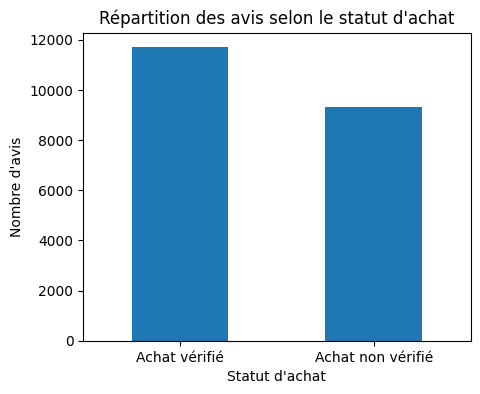

In [16]:
plt.figure(figsize=(5, 4))

verified_distribution["Nombre"].plot(kind="bar")

plt.title("Répartition des avis selon le statut d'achat")
plt.xlabel("Statut d'achat")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)

plt.show()

On observe que 11 698 avis, soit environ 55,7 % du dataset, proviennent d’achats vérifiés.  
Les avis non vérifiés représentent 9 302 avis, soit environ 44,3 %.

La répartition est donc relativement équilibrée, même si les achats vérifiés sont légèrement plus nombreux.

## Relation entre les achats vérifiés et la classe des avis

Nous croisons la colonne `VERIFIED_PURCHASE` avec la variable cible `LABEL` afin d’observer la répartition des faux avis et des avis authentiques selon le statut d’achat vérifié.

In [17]:
verified_label_count = pd.crosstab(
    df["VERIFIED_PURCHASE"],
    df["LABEL"]
)

verified_label_percent = pd.crosstab(
    df["VERIFIED_PURCHASE"],
    df["LABEL"],
    normalize="index"
) * 100

verified_label_summary = verified_label_count.astype(str) + " (" + verified_label_percent.round(2).astype(str) + "%)"

verified_label_summary

LABEL,Avis authentique,Faux avis
VERIFIED_PURCHASE,,
Achat non vérifié,1679 (18.05%),7623 (81.95%)
Achat vérifié,8821 (75.41%),2877 (24.59%)


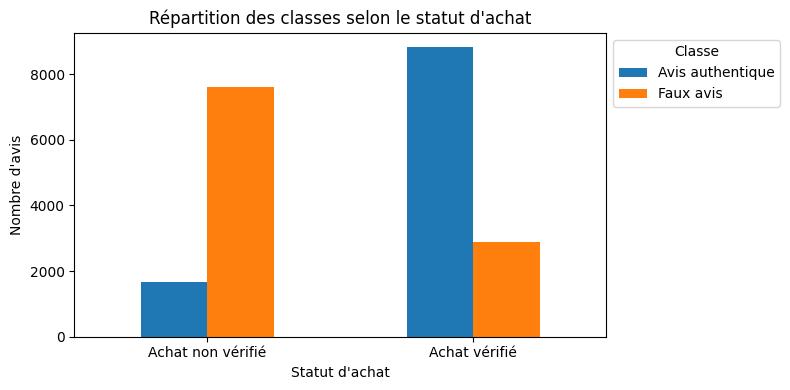

In [30]:
verified_label_plot = pd.crosstab(
    df["VERIFIED_PURCHASE"],
    df["LABEL"]
)

ax = verified_label_plot.plot(kind="bar", figsize=(8, 4))

plt.title("Répartition des classes selon le statut d'achat")
plt.xlabel("Statut d'achat")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)

plt.legend(title="Classe", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

Le croisement entre `VERIFIED_PURCHASE` et `LABEL` montre une relation importante entre le statut d’achat et la classe de l’avis.

Parmi les avis non vérifiés, environ 82 % correspondent à des faux avis.  
À l’inverse, parmi les avis associés à un achat vérifié, environ 75 % correspondent à des avis authentiques.

Cette différence met ainsi en évidence une association entre le statut d’achat vérifié et la classe des avis.

## Analyse des catégories de produits

Nous analysons la colonne `PRODUCT_CATEGORY`, qui indique la catégorie du produit associé à chaque avis.  
Cette étape permet d’identifier les catégories les plus représentées dans le dataset.

In [19]:
print("Nombre de catégories :", df["PRODUCT_CATEGORY"].nunique())

Nombre de catégories : 30


In [20]:
category_distribution = pd.DataFrame({
    "Nombre": df["PRODUCT_CATEGORY"].value_counts(),
    "Pourcentage": df["PRODUCT_CATEGORY"].value_counts(normalize=True) * 100
})

category_distribution

,Nombre,Pourcentage
PRODUCT_CATEGORY,,
PC,700,3.333333
Wireless,700,3.333333
Baby,700,3.333333
Office Products,700,3.333333
Beauty,700,3.333333
Health & Personal Care,700,3.333333
Toys,700,3.333333
Kitchen,700,3.333333
Furniture,700,3.333333


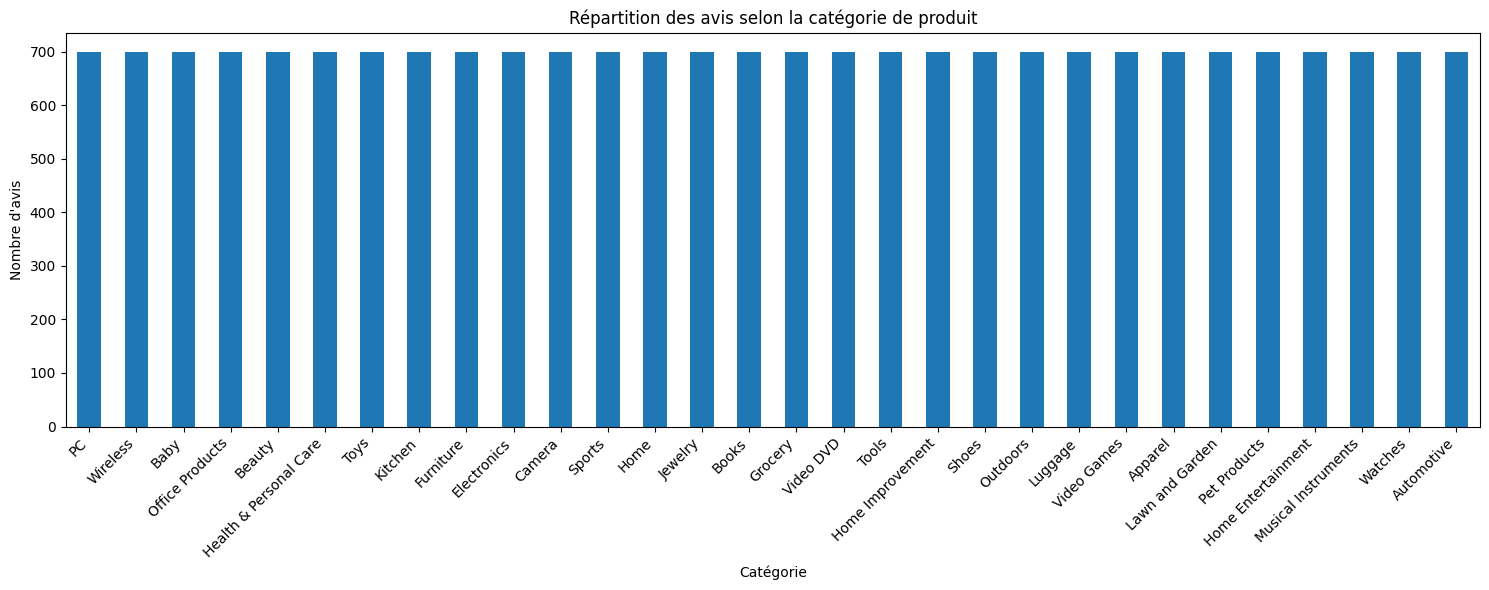

In [21]:
plt.figure(figsize=(15, 6))
category_distribution["Nombre"].plot(kind="bar")

plt.title("Répartition des avis selon la catégorie de produit")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Le dataset contient 30 catégories de produits.  
Chaque catégorie contient exactement 700 avis, soit environ 3,33 % du dataset.

La répartition des catégories est donc parfaitement équilibrée. Cela permet d’éviter qu’une catégorie de produit soit surreprésentée par rapport aux autres.

## Relation entre les catégories de produits et la classe des avis

Nous croisons la colonne `PRODUCT_CATEGORY` avec la variable cible `LABEL` afin d’observer la répartition des faux avis et des avis authentiques selon les catégories de produits.

In [22]:
category_label_count = pd.crosstab(
    df["PRODUCT_CATEGORY"],
    df["LABEL"]
)

category_label_percent = pd.crosstab(
    df["PRODUCT_CATEGORY"],
    df["LABEL"],
    normalize="index"
) * 100

category_label_summary = (
    category_label_count.astype(str)
    + " ("
    + category_label_percent.round(2).astype(str)
    + "%)"
)

category_label_summary.columns.name = None
category_label_summary.index.name = "Catégorie de produit"

category_label_summary

,Avis authentique,Faux avis
Catégorie de produit,,
Apparel,350 (50.0%),350 (50.0%)
Automotive,350 (50.0%),350 (50.0%)
Baby,350 (50.0%),350 (50.0%)
Beauty,350 (50.0%),350 (50.0%)
Books,350 (50.0%),350 (50.0%)
Camera,350 (50.0%),350 (50.0%)
Electronics,350 (50.0%),350 (50.0%)
Furniture,350 (50.0%),350 (50.0%)
Grocery,350 (50.0%),350 (50.0%)


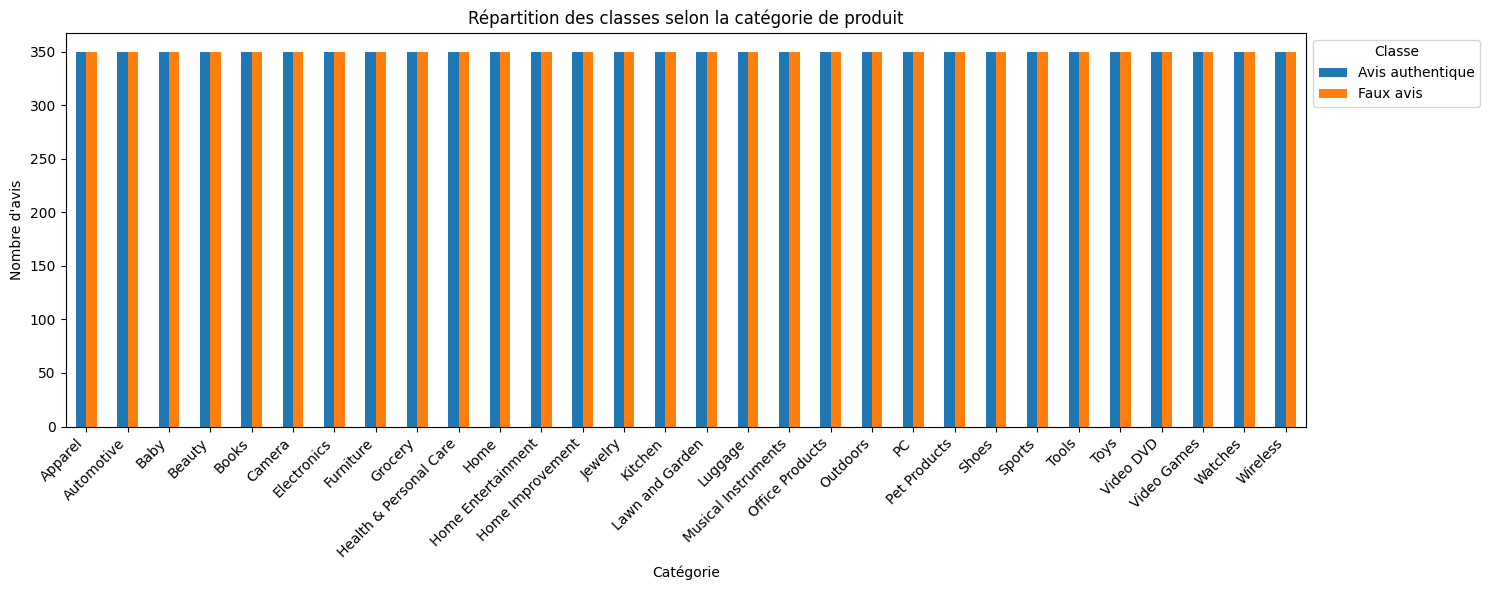

In [23]:
category_label_plot = pd.crosstab(
    df["PRODUCT_CATEGORY"],
    df["LABEL"]
)

ax = category_label_plot.plot(kind="bar", figsize=(15, 6))

plt.title("Répartition des classes selon la catégorie de produit")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Classe", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

Le croisement entre `PRODUCT_CATEGORY` et `LABEL` montre que chaque catégorie contient exactement 350 faux avis et 350 avis authentiques.

La répartition est donc parfaitement équilibrée dans toutes les catégories, avec 50 % de faux avis et 50 % d’avis authentiques pour chacune.

Cela montre que la variable cible n’est pas déséquilibrée selon les catégories de produits. Ainsi, aucune catégorie ne favorise une classe particulière dans le dataset.

## Analyse de la longueur des avis

Nous analysons la longueur des avis à partir de la colonne `REVIEW_TEXT`.  
Pour cela, nous calculons deux nouvelles variables : le nombre de caractères et le nombre de mots pour chaque avis.

In [24]:
df["review_char_count"] = df["REVIEW_TEXT"].astype(str).apply(len)
df["review_word_count"] = df["REVIEW_TEXT"].astype(str).apply(lambda x: len(x.split()))

df[["REVIEW_TEXT", "review_char_count", "review_word_count"]].head()

,REVIEW_TEXT,review_char_count,review_word_count
0,"When least you think so, this product will save the day. Just keep it around just in case you need it for something.",116,23
1,Lithium batteries are something new introduced in the market there average developing cost is relatively high but Stallion doesn't compromise on quality and provides us with the best at a low cost...,404,69
2,I purchased this swing for my baby. She is 6 months now and has pretty much out grown it. It is very loud and doesn't swing very well. It is beautiful though. I love the colors and it has a lot of...,248,52
3,I was looking for an inexpensive desk calcolatur and here it is. It works and does everything I need. Only issue is that it tilts slightly to one side so when I hit any keys it rocks a little bit....,212,44
4,"I only use it twice a week and the results are great. I have used other teeth whitening solutions and most of them, for the same results I would have to use it at least three times a week. Will ke...",331,66


In [25]:
length_stats = pd.DataFrame({
    "Nombre de caractères": [
        df["review_char_count"].mean(),
        df["review_char_count"].median(),
        df["review_char_count"].min(),
        df["review_char_count"].max()
    ],
    "Nombre de mots": [
        df["review_word_count"].mean(),
        df["review_word_count"].median(),
        df["review_word_count"].min(),
        df["review_word_count"].max()
    ]
}, index=[
    "Moyenne",
    "Médiane",
    "Minimum",
    "Maximum"
])

length_stats.round(2)

,Nombre de caractères,Nombre de mots
Moyenne,372.3,69.19
Médiane,236.0,45.00
Minimum,98.0,13.00
Maximum,16188.0,2847.00


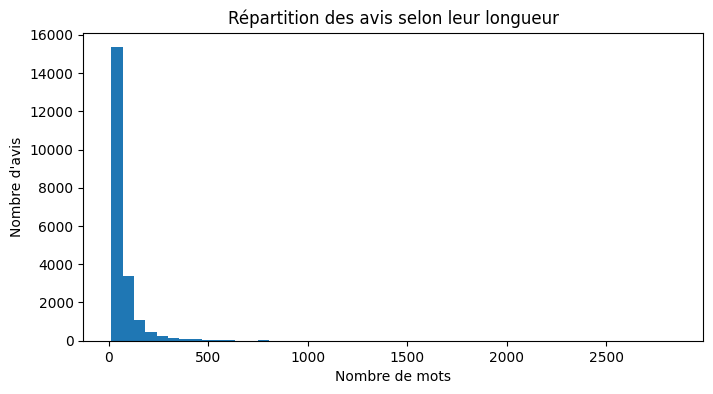

In [26]:
plt.figure(figsize=(8, 4))
df["review_word_count"].plot(kind="hist", bins=50)

plt.title("Répartition des avis selon leur longueur")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'avis")

plt.show()

L’analyse de la longueur des avis montre que les textes ont des longueurs variables.

En moyenne, un avis contient environ 69 mots, tandis que la médiane est de 45 mots.  
Cela signifie que la majorité des avis sont relativement courts.

Cependant, certains avis sont beaucoup plus longs, avec un maximum de 2 847 mots.  
Cette présence d’avis très longs explique l’étalement de la distribution vers la droite.

## Relation entre la longueur des avis et la classe

Nous comparons la longueur des avis selon leur classe afin d’observer si les faux avis et les avis authentiques présentent des différences en termes de nombre de mots.

In [27]:
length_mean_by_label = df.groupby("LABEL")[[
    "review_char_count",
    "review_word_count"
]].mean()

length_mean_by_label = length_mean_by_label.rename(
    columns={
        "review_char_count": "Nombre moyen de caractères",
        "review_word_count": "Nombre moyen de mots"
    }
)

length_mean_by_label.round(2)

,Nombre moyen de caractères,Nombre moyen de mots
LABEL,,
Avis authentique,428.06,79.09
Faux avis,316.54,59.29


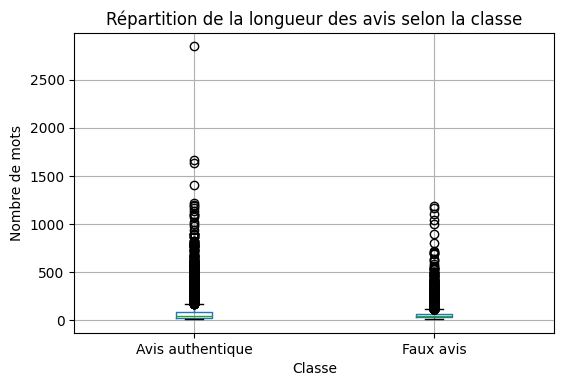

In [28]:
ax = df.boxplot(
    column="review_word_count",
    by="LABEL",
    figsize=(6, 4)
)

plt.title("Répartition de la longueur des avis selon la classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Nombre de mots")

plt.show()

La comparaison de la longueur des avis selon la classe montre que les avis authentiques sont en moyenne plus longs que les faux avis.

Les faux avis contiennent en moyenne environ 59 mots, tandis que les avis authentiques contiennent environ 79 mots.  
Cette différence met en évidence des variations de longueur entre les deux classes. 

Le graphique montre également la présence de nombreux avis très longs dans les deux classes.

## Conclusion

Cette exploration montre que le dataset contient 21 000 avis Amazon répartis sur 30 catégories de produits.  
La variable cible est parfaitement équilibrée, avec 10 500 faux avis et 10 500 avis authentiques.

Les catégories de produits sont également équilibrées, avec 700 avis par catégorie, dont 350 faux avis et 350 avis authentiques.  
L’analyse du statut d’achat vérifié montre une relation importante avec la classe de l’avis : les avis non vérifiés sont majoritairement des faux avis, tandis que les avis associés à un achat vérifié sont majoritairement authentiques.

Enfin, l’analyse de la longueur des avis montre que les avis authentiques sont en moyenne plus longs que les faux avis.  
Ces premières observations permettent de mieux caractériser le jeu de données et de mettre en évidence certaines différences entre les deux classes. Pour la suite des expérimentations, seule la colonne `REVIEW_TEXT` est utilisée comme donnée d’entrée des modèles, les autres variables étant conservées uniquement à des fins descriptives.

La prochaine étape consistera à préparer les textes des avis pour l’entraînement des modèles de classification.